In [27]:
# --- Minimal, clean header: widget + cvxopt ---
%pip install -q ipympl ipywidgets qpsolvers cvxopt osqp scipy

# 只保留这一句，别再 load_ext / nbextension
%matplotlib widget

# 可选自检（安全显示 backend 与 solvers）
import sys, matplotlib
from qpsolvers import available_solvers
sols = available_solvers() if callable(available_solvers) else available_solvers
print("Matplotlib backend:", matplotlib.get_backend())
print("qpsolvers:", sols)
import cvxopt  # 能 import 就 OK


Note: you may need to restart the kernel to use updated packages.
Matplotlib backend: widget
qpsolvers: ['cvxopt', 'osqp']


In [28]:
# Q1
%matplotlib widget
import numpy as np
import scipy.sparse as sp
from qpsolvers import solve_qp, available_solvers
import quadrotor
import matplotlib.pyplot as plt

A = quadrotor.A.copy()
B = quadrotor.B.copy()

nx = A.shape[0]
nu = B.shape[1]          # 注意：nu 来自 B 的列数

N = 500                  # 需要的话改 300
try:
    x0 = quadrotor.x0.copy()
except AttributeError:
    x0 = np.zeros(nx)

x_desired = np.array([-3.0, 0.0, 3.0, 0.0, 0.0, 0.0])
Q = np.diag([10, 0.1, 10, 0.1, 2, 0.1])
R = 0.1*np.eye(nu)
umax = 5.0
vmax = 2.0
VEL_IDXS = [1, 3]        # vx, vy

A_sp = sp.csc_matrix(A)
B_sp = sp.csc_matrix(B)

# === 工具函数保持 ===
def kron_eye(M, N):
    return sp.kron(sp.eye(N, format='csc'), sp.csc_matrix(M), format='csc')

def build_batch_matrices_sparse(A_sp, B_sp, N):
    """
    返回：
      Sx: vstack([A, A^2, ..., A^N])        形状 (N*nx, nx)
      Su: 下三角块矩阵，每块 A^(i-1-j) B     形状 (N*nx, N*nu)
    """
    nx = A_sp.shape[0]
    nu = B_sp.shape[1]

    # --- Sx: 垂直堆叠 A^k ---
    blocks = []
    Ak = sp.eye(nx, format='csc')
    for _ in range(N):
        Ak = A_sp @ Ak           # Ak = A^k
        blocks.append(Ak)        # (nx, nx)
    Sx = sp.vstack(blocks, format='csc')    # (N*nx, nx)

    # --- Su: 下三角块矩阵 ---
    A_pows = {0: sp.eye(nx, format='csc')}
    for p in range(1, N):
        A_pows[p] = A_sp @ A_pows[p-1]

    zero_nx_nu = sp.csc_matrix((nx, nu))
    block_rows = []
    for i in range(N):
        row_blocks = []
        for j in range(N):
            row_blocks.append(A_pows[i-j] @ B_sp if j <= i else zero_nx_nu)
        block_rows.append(row_blocks)
    Su = sp.bmat(block_rows, format='csc')  # (N*nx, N*nu)

    return Sx, Su

# === 批量矩阵 ===
Sx, Su = build_batch_matrices_sparse(A_sp, B_sp, N)
print("Sx:", Sx.shape, "Su:", Su.shape)  # 期望 (N*nx, nx), (N*nx, N*nu)

# === 代价（批量） ===
Qbar = kron_eye(Q, N)
Rbar = kron_eye(R, N)

Xd  = np.tile(x_desired, N)           # (N*nx,)
tmp = (Sx @ x0) - Xd                  # (N*nx,)

# H 稀疏并对称化
H = (Su.T @ Qbar @ Su) + Rbar
H = 0.5 * (H + H.T)

# g 统一成 1D ndarray
g = (Su.T @ Qbar @ tmp)
g = g.toarray().ravel() if sp.issparse(g) else np.asarray(g).ravel()

# === 控制上下界 ===
lb = -umax * np.ones(N*nu)
ub =  umax * np.ones(N*nu)

# === 速度约束：|vx|, |vz| <= vmax ===
rows = []
for k in range(N):
    base = k * nx
    for idx in VEL_IDXS:   # [1, 3]  # vx, vz
        rows.append(base + idx)

E = sp.csc_matrix(
    (np.ones(len(rows)), (np.arange(len(rows)), rows)),
    shape=(len(rows), N * nx)
)

offset = (E @ (Sx @ x0)).ravel()
G = sp.vstack([E @ Su, -E @ Su], format="csc")
h = np.hstack([
    vmax * np.ones(E.shape[0]) - offset,
    vmax * np.ones(E.shape[0]) + offset
])

print("G shape:", G.shape)          # 期望 (2*2N, N*nu)
print("h shape:", h.shape)          # 期望 (2*2N,)
print("lb/ub shape:", lb.shape, ub.shape)  # (N*nu,)

# === 用 qpsolvers 的 cvxopt 求解（满足题目要求） ===
U = solve_qp(P=H, q=g, G=G, h=h, A=None, b=None, lb=lb, ub=ub, solver="cvxopt")
assert U is not None, "QP failed：请确认已安装 qpsolvers[cvxopt] 并可用。"

# === 还原轨迹与控制（不画图） ===
traj = (Sx @ x0) + (Su @ U)      # (N*nx,)
X = traj.reshape(N, nx)          # (N, nx)
U = U.reshape(N, nu)             # (N, nu)

# === 轻量检查（文本输出，Q1 不作图） ===
vx = X[:, 1]; vz = X[:, 3]
print("max |vx| =", np.max(np.abs(vx)))
print("max |vz| =", np.max(np.abs(vz)))
print("max |u|  =", np.max(np.abs(U)))


Sx: (3000, 6) Su: (3000, 1000)
G shape: (2000, 1000)
h shape: (2000,)
lb/ub shape: (1000,) (1000,)
max |vx| = 1.9999999988980552
max |vz| = 1.9999999637438408
max |u|  = 4.999999962928412


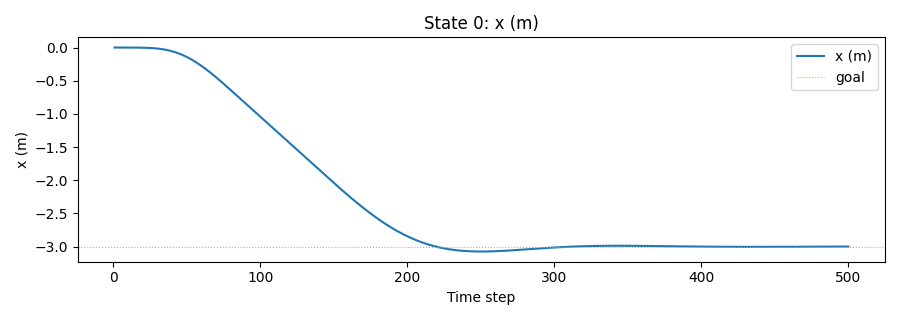

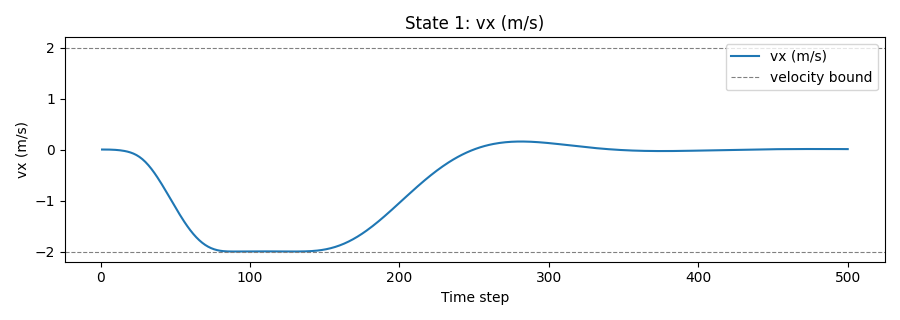

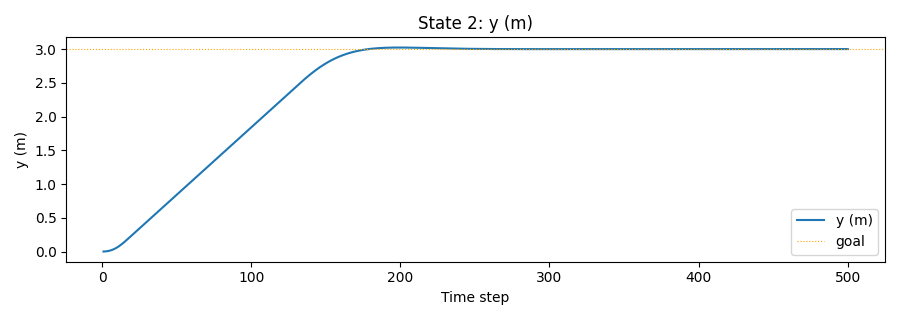

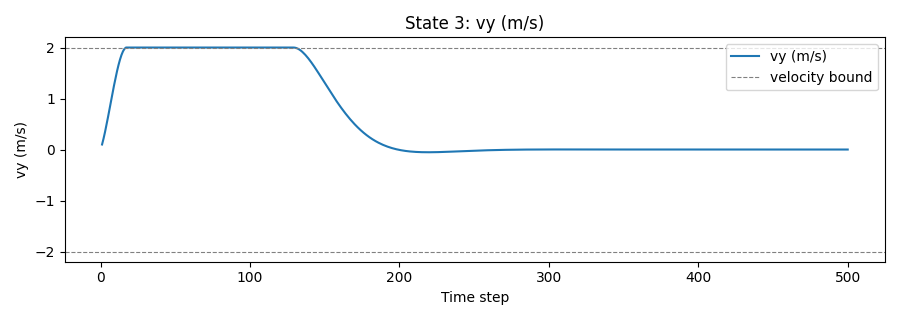

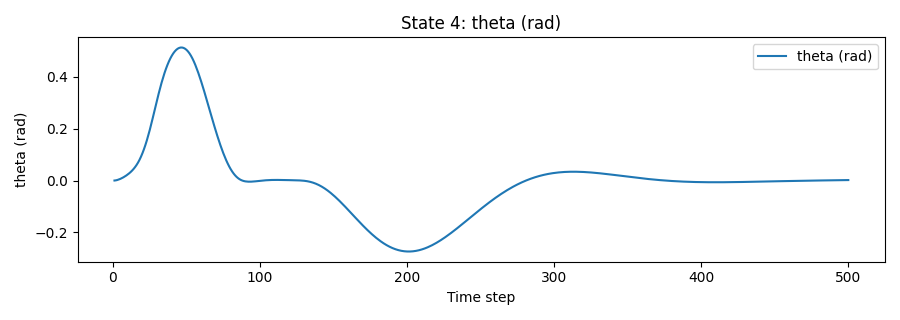

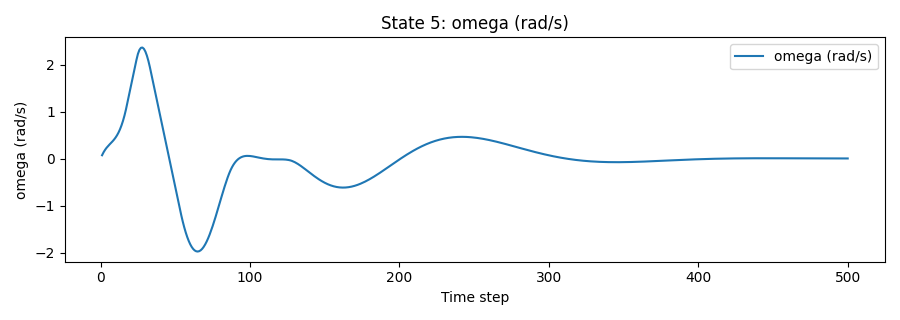

In [29]:
# Q2 === Plot all states x=[x, vx, y, vy, theta, omega] versus time ===
state_names = ["x (m)", "vx (m/s)", "y (m)", "vy (m/s)", "theta (rad)", "omega (rad/s)"]
t = np.arange(1, N + 1)

for i, name in enumerate(state_names):
    plt.figure(figsize=(9, 3.2))
    plt.plot(t, X[:, i], label=name)

    # === 标签与标题 ===
    plt.xlabel("Time step")
    plt.ylabel(name)
    plt.title(f"State {i}: {name}")

    # === 速度约束参考线 ===
    if i in [1, 3]:  # vx, vy
        plt.axhline(2.0, linestyle="--", linewidth=0.8, color="gray", label="velocity bound")
        plt.axhline(-2.0, linestyle="--", linewidth=0.8, color="gray")

    # === 期望状态参考线（仅对非零目标画） ===
    if i in [0, 2, 4] and abs(x_desired[i]) > 1e-8:
        plt.axhline(x_desired[i], linestyle=":", linewidth=0.8, color="orange", label="goal")

    # === 自动生成图例 ===
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles, labels, loc="best")

    plt.tight_layout()
    plt.show()


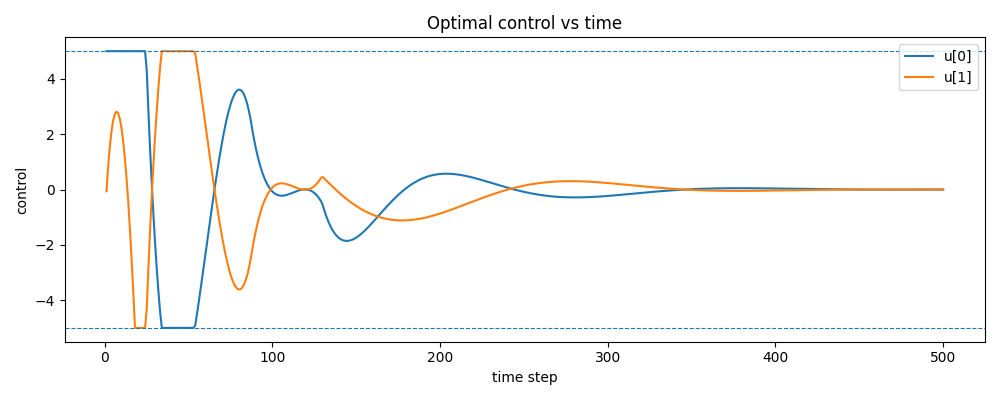

In [30]:
# q3 === Plot optimal controls u versus time ===
t = np.arange(1, N+1)
ctrl_names = [f"u[{j}]" for j in range(U.shape[1])]

plt.figure(figsize=(10,4))
for j, name in enumerate(ctrl_names):
    plt.plot(t, U[:, j], label=name)
plt.axhline( umax, linestyle='--', linewidth=0.8)
plt.axhline(-umax, linestyle='--', linewidth=0.8)
plt.title('Optimal control vs time')
plt.xlabel('time step'); plt.ylabel('control')
plt.legend(); plt.tight_layout()
plt.show()


In [31]:
# === Animation (place this in Q3 or a separate "Visualization" cell) ===
# 要求：已得到 X (N,nx), U (N,nu), x0 (nx,), 且 Q1 用 solver="cvxopt" 求解完毕

# === Animation (after Q3) ===
try:
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    pass

x0_col = x0.reshape(-1, 1)   # (nx,1)
u_anim = U.T                 # (nu,N)

try:
    quadrotor.animate_robot(x0_col, u_anim, goal=[-3, 3])
except Exception as e:
    print("Animation skipped:", e)



<source type="video/mp4" src="data:video/mp4;base64,AAAAIGZ0eXBNNFYgAAACAE00ViBpc29taXNvMmF2YzEAAAAIZnJlZQAAL6dtZGF0AAACrgYF//+q
3EXpvebZSLeWLNgg2SPu73gyNjQgLSBjb3JlIDE2MyByMzA2MCA1ZGI2YWE2IC0gSC4yNjQvTVBF
Ry00IEFWQyBjb2RlYyAtIENvcHlsZWZ0IDIwMDMtMjAyMSAtIGh0dHA6Ly93d3cudmlkZW9sYW4u
b3JnL3gyNjQuaHRtbCAtIG9wdGlvbnM6IGNhYmFjPTEgcmVmPTMgZGVibG9jaz0xOjA6MCBhbmFs
eXNlPTB4MzoweDExMyBtZT1oZXggc3VibWU9NyBwc3k9MSBwc3lfcmQ9MS4wMDowLjAwIG1peGVk
X3JlZj0xIG1lX3JhbmdlPTE2IGNocm9tYV9tZT0xIHRyZWxsaXM9MSA4eDhkY3Q9MSBjcW09MCBk
ZWFkem9uZT0yMSwxMSBmYXN0X3Bza2lwPTEgY2hyb21hX3FwX29mZnNldD0tMiB0aHJlYWRzPTEg
bG9va2FoZWFkX3RocmVhZHM9MSBzbGljZWRfdGhyZWFkcz0wIG5yPTAgZGVjaW1hdGU9MSBpbnRl
cmxhY2VkPTAgYmx1cmF5X2NvbXBhdD0wIGNvbnN0cmFpbmVkX2ludHJhPTAgYmZyYW1lcz0zIGJf
cHlyYW1pZD0yIGJfYWRhcHQ9MSBiX2JpYXM9MCBkaXJlY3Q9MSB3ZWlnaHRiPTEgb3Blbl9nb3A9
MCB3ZWlnaHRwPTIga2V5aW50PTI1MCBrZXlpbnRfbWluPTEwIHNjZW5lY3V0PTQwIGludHJhX3Jl
ZnJlc2g9MCByY19sb29rYWhlYWQ9NDAgcmM9Y3JmIG1idHJlZT0xIGNyZj0yMy4wIHFjb21wPTAu
NjAgcXBtaW49MCBxcG1heD02OSBxcHN0ZXA9NCBpcF9yYXRpbz0xLjQwIGFxPTE6MS4wMACAAAAR
MGWIhAAQ//73gb8yy18iuslx+ed9LKzPPOQ8cl2JrrjQAAADAAADAAFHh7Xrjd2DW0nQAAAawAOk
I1P/T9142nEA0EvtHqXzsuamUFIZSwxCA2KdK9gGiLwQ+UaHGKXushqSue2ZF9TSqIzQEB+Suz6P
kYW3aK3OpCt93eWmYkVdr4w0MrHB4FQkEshT/eeeQAW5H7BIZLVHdtoQk2aQm2/1CQrM8vUPyB5G
tQcfqIQyY95leoRT037B1neltayvcKYqow9bpAA+65ttcefuh5E+lxt3HY8Rvc+O/QtAi9YlNLpi
yFvFv/Bo6yYS0C4ViI+6CYcPRRzp0FI5mnG2sClhsojwI8oh/L9OtfZt+tSkSEdDNvCKsoQiVRM1
0hOyRU4/eWNebfjknxw/H8mtQnUI44CxNhCS+DQx3yhidL6+c/2WFhqCNS/VVrFUhfLiX2r9H/mV
p8vDEgjMXSLdNifFH8Y5XPHh/tgfKKLjMI7gqQC+nH8uF782+yDQX2cvd0HjPEyHF9Ke6aYoUX41
ukIBfdyJCjX/GgzBbl28F+jey8/waS72cB5DP5t+FjgyLSQlXz5A1zzy0wkpZ8Bx3OKC7B8Gi7uM
YOAqfpOjMKNzeg1gQndnUCIEL6iAIn632NsK0KouDYHbdCkjWfQk8ZdIZbfFZn/S3JyiOWHTYzPY
oK6GJ0bQRf7x+BrDcDq43elihPo6zRkU8CczqhmfOdouYsEnzyOsDXOHsUFadfDWkv8dYwMzEp9R
UZqn7LSlL14kJ1PM1LqDwq+oYl1lclNW+K4Ox5H+NNSvBx5wYMs48pfS7U71XXlMIXvvmp29TG5e
tmbdYQjUk9bpSy1EHvS11S6wjk0yceiJVCOF7nAcvXPmszYCvwQIZUYl1twIGU4NRzWMqEKNhkdJ
cxZOlMtvHUFuUFXqhwTRjqFlRNr4uQKnlDcgfnXar5cPOt3pQ5QKIlKKSiTyv2uJvazNic+4W5LY
XkkHqe7e0aH1R32erMyfvnpcmLQvPWvsqMG+UrodvIjoeJ1gdvMVk/qbf+XsQqkJL5s9Hlet9Foq
PDQi0IP+p6NosT3q8dAgzgf4qjZP2UKB9/chhmuu36RoD2GPHasHBbZeqUJ7mh+WKC679EgGvfLm
4AAAKCHLefXKRH54/6HffmBtc+SpNNMMcIC84LrZ6y22SJCkDkUb8Cn5G+ORLjCwXlwWyCDd1j3o
zbn8vw29vxAZsr1c0pEdM7CUheLiPw9X/Hgs6McaZ18n7WO3JE5li5lyuySv8Y7YViirebwFwVnh
mObNUxvoTX0cK3AkXD6EJn9XMKAv5bCEraOppv3n1s9D+qn+21ZfM5ynt9uJWDIFt0ajBOlW1XR7
P+VjXpob9l+nKTgpnA22AV0rFXZE5u53LGxrJJkAATXTglMmnzE4jE3/GukiXlOSu/HaXGTsuG8L
7BEhTMwuQMxYClKCDfbVRs2ZKD6rhmoLq+Ung1sY1HmQ6upxfFXVWSkRmilAXvUXGCP34R04mzVO
1MWErFwz7ij/HRi4dwTFZNCWE3+P9jQv5U/XIGiN5Cvc3vxTgs+HADTaEPCrOZ+UsDZXsMR2auyY
FvuObAAANKI0/oAEFdjbHyyIcW8A5vD2DlzfkrQ+vfMncQJEj+cMl5y+EooqkTQGZT5TanXE22Mm
46rebGV9WXCUD9de/r4oDRrJbZV7gsw0J3Ww5wXSMNR5wN3aS+P8VC5RTqwomdYqsfzvUchpHwoJ
o1kB+X6/MuvtiDffTQQ3p/LAVuIf+bw5Qlj/kQFwrAAurZhlrwrLeeOQkZDS57PKEk7+ZMKBYF6k
K5zgy8ZdP8vW7IPZeh3xe+1vOzOug7Pkun3FnIf7Mw8xRtPQwGqUw07NWMfEdrmA1Jn6zFlAyD9c
luqj/9Y4wo7XtKAWiwUgerZguhoWLDxPTzkvOzXx3wKfTY9SO9ABwKLnQ5Pu7/r3wc943hPZw7WR
VutoH4Ats0Nkww4qcs9AACXwG7R8uvC3GTCnYdzIgdfwkpcLEWLVPciLsEmaRgsX1aki//FKn+u4
f8sNA98JZwAY8YNb406mLEMyQparNylhZme+5OXOhTuoCrrjKIn8SgSt1b1+lXtT0X18CCLA4GRg
eSD8G9PRR7qFrgeAVqaEJ1L6WBnOiTNYuq9DCGJT/RUBmyPB/Ax3VHEeb6XzoAkTOozXzX2iI8Aa
4vu2H95/YGcSJCfW8dzWRNM9Iq/KZhNOGf0zuix9DjeUYeLWo5EW6FQ18z4veFzhS11504yL887A
Z10fWmzaSSLfuozOoKz3jutP7aEY1gjyz2rF5r3E1PMy9NHXiMGukJeG/2Yp47XMHcOBw3GsCAdU
vZRkdgGiJwY+w9ReicCKyBDwVdBx6uXfwesWbzpVQWCyAZvAMXix9ruszEe75YomxvK0/SMTlq6z
OmZMJUjiSFEqFG5/4FOvzhq8gUavE2mGa8geEs0mUWTC0YUtVins1B5KVnEDJxtc7kiQBNHVaYmo
TMgWQLao/rex7TznNBW7I/XZQT2D080/7/j+2tFmXJHa8D5DYh4+WQbz5Rc/0w8PhbeUb39P0Gg8
a8sVcG/iwUanX4wzRwclC9rOfwb1WItcnRlAiOHU84jvI2p0VDQTt32Dw/+yGCjbzmYzd2JrQ5vz
y2vOSe9O1W7QECP4Z+4vx7ZSaitr9q3gSHu1PlpA1o3pDGY8DbgL7Dra7tYpPeA67OW1gQ6jFMVb
KOEnzBVa/v4nVE6I6agbeglRfZuGbtby+KRWq/5njaU9ptKPhdWWmpN1mxnQ+jet0l/fGVnKkb+V
KM4C0crk4XqWmG0VW9nXbpvlLib0WWDuGiZkP/pFJTjL37AYBHbCdgSH01cq7v/rmW72BSeFMkqn
ko/MzJhg1KDPgDOnPsrbR

Unconstrained (NumPy solve) done. Shapes -> X_free: (500, 6) U_free: (500, 2)
=== COST ===
with bounds (Series 2): J = 7131.696
no bounds  (Series 1): J = 4578.451

=== VELOCITY PEAKS ===
with bounds: max|vx|=2.000, max|vy|=2.000
no  bounds: max|vx|=4.041, max|vy|=6.999

=== CONTROL PEAK ===
with bounds: max|u| = 5.000
no  bounds: max|u| = 40.501

=== CONSTRAINT CHECKS ===
with bounds: fraction at control bound (tol=0.0001) = 8.80%
no  bounds: total velocity violation (L1 over time) = 273.657
no  bounds: total control  violation (L1 over time) = 364.489


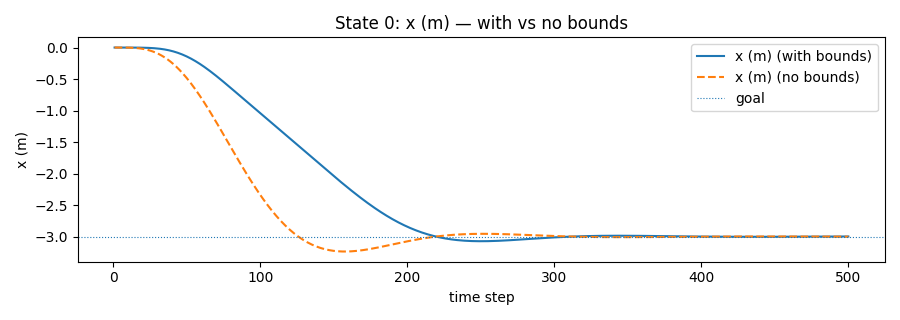

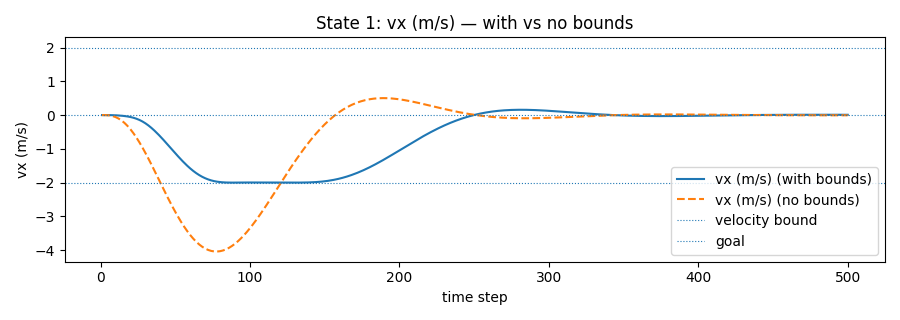

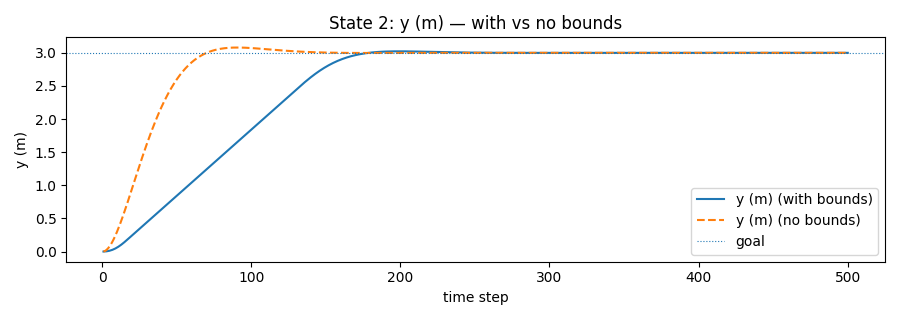

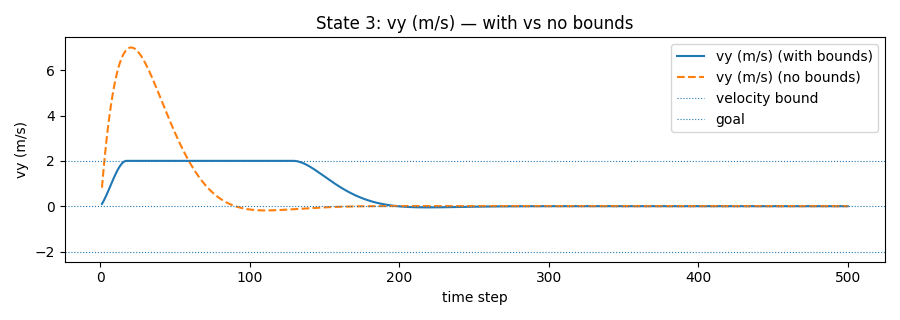

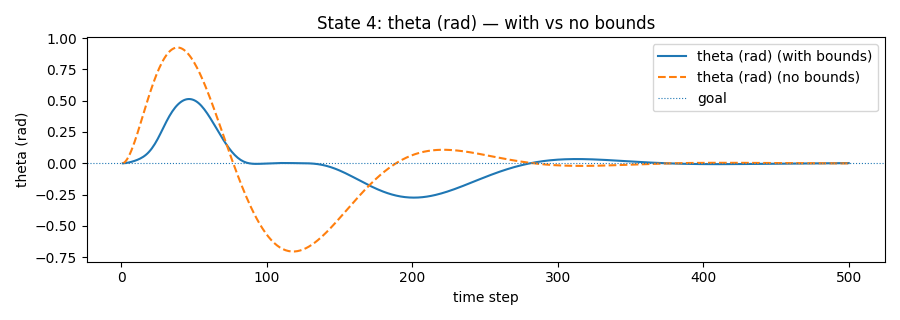

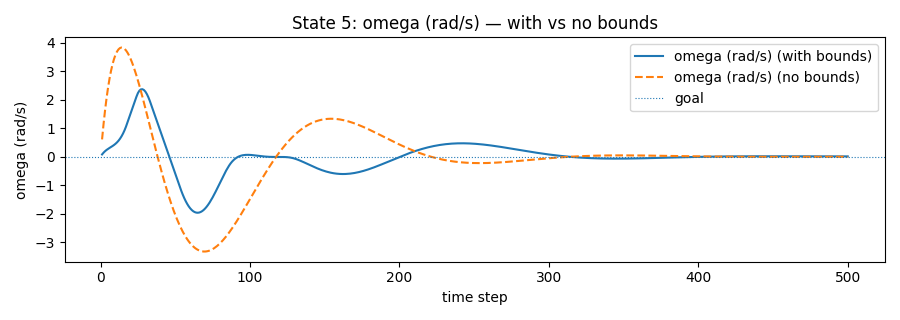

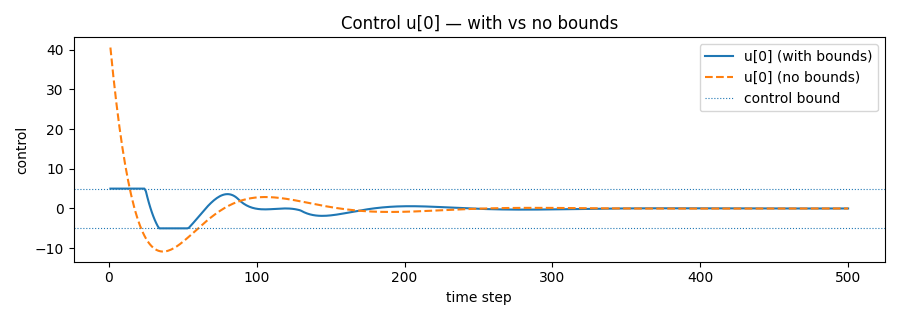

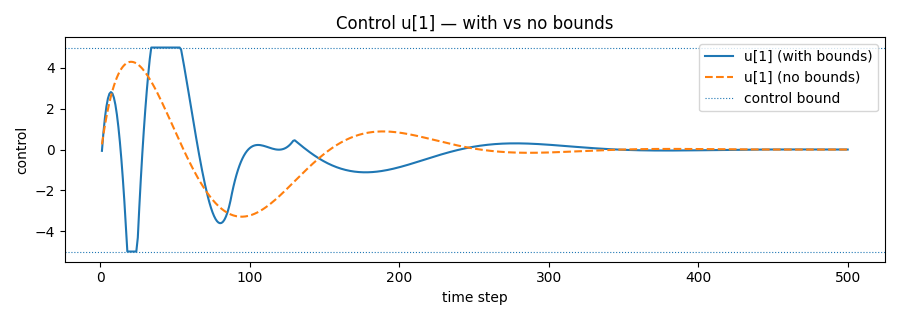

In [32]:
# === Q4: Series 2 (bounded, from cvxopt) vs Series 1 (unbounded, NumPy solve) ===

# --- Series 1 (no bounds) by linear solve (no matrix inverse) ---
H_dense = (H + H.T).toarray() * 0.5
H_dense += 1e-12 * np.eye(H_dense.shape[0])  # small Tikhonov for stability (optional)
rhs = -g  # KKT stationarity: H U + g = 0  ->  H U = -g
U_free = np.linalg.solve(H_dense, rhs).reshape(N, nu)

traj_free = (Sx @ x0) + (Su @ U_free.ravel())
X_free = np.asarray(traj_free).reshape(N, nx)

print("Unconstrained (NumPy solve) done. Shapes -> X_free:", X_free.shape, "U_free:", U_free.shape)

# --- metrics helpers (single definition) ---
def total_cost(X, U, x_desired, Q, R):
    xerr = X - x_desired.reshape(1, -1)
    Jx = np.sum(np.einsum('ij,ij->i', xerr @ Q, xerr))
    Ju = np.sum(np.einsum('ij,ij->i', U @ R, U))
    return 0.5 * (Jx + Ju)

def stats(v):
    return dict(max=float(np.max(v)), mean=float(np.mean(v)), rms=float(np.sqrt(np.mean(v**2))))

# --- scalar metrics & constraint checks ---
J_constr = total_cost(X, U, x_desired, Q, R)
J_free   = total_cost(X_free, U_free, x_desired, Q, R)

vx_c, vy_c = X[:, 1], X[:, 3]
vx_f, vy_f = X_free[:, 1], X_free[:, 3]

tol = 1e-4  # tolerance for "at bound" due to interior-point strict feasibility
sat_ctrl_frac = float(np.mean(np.any(np.abs(U) >= umax - tol, axis=1)))
viol_v_free = np.maximum(0.0, np.abs(vx_f) - vmax) + np.maximum(0.0, np.abs(vy_f) - vmax)
viol_u_free = np.maximum(0.0, np.abs(U_free) - umax)

print("=== COST ===")
print(f"with bounds (Series 2): J = {J_constr:.3f}")
print(f"no bounds  (Series 1): J = {J_free:.3f}")

print("\n=== VELOCITY PEAKS ===")
print(f"with bounds: max|vx|={np.max(np.abs(vx_c)):.3f}, max|vy|={np.max(np.abs(vy_c)):.3f}")
print(f"no  bounds: max|vx|={np.max(np.abs(vx_f)):.3f}, max|vy|={np.max(np.abs(vy_f)):.3f}")

print("\n=== CONTROL PEAK ===")
print(f"with bounds: max|u| = {np.max(np.abs(U)):.3f}")
print(f"no  bounds: max|u| = {np.max(np.abs(U_free)):.3f}")

print("\n=== CONSTRAINT CHECKS ===")
print(f"with bounds: fraction at control bound (tol={tol:g}) = {sat_ctrl_frac:.2%}")
print(f"no  bounds: total velocity violation (L1 over time) = {np.sum(viol_v_free):.3f}")
print(f"no  bounds: total control  violation (L1 over time) = {np.sum(np.abs(viol_u_free)):.3f}")

# --- overlay plots: states (goal line on all dims: per your preference) ---
state_names = ["x (m)", "vx (m/s)", "y (m)", "vy (m/s)", "theta (rad)", "omega (rad/s)"]
t = np.arange(1, N + 1)
save_figs = False

for i, name in enumerate(state_names):
    plt.figure(figsize=(9, 3.2))
    plt.plot(t, X[:, i],      label=f"{name} (with bounds)")
    plt.plot(t, X_free[:, i], label=f"{name} (no bounds)", linestyle="--")
    if i in [1, 3]:  # vx, vy bounds
        plt.axhline( vmax, linestyle=":", linewidth=0.8, label="velocity bound")
        plt.axhline(-vmax, linestyle=":", linewidth=0.8)
    plt.axhline(x_desired[i], linestyle=":", linewidth=0.8, label="goal")
    plt.xlabel("time step"); plt.ylabel(name)
    plt.title(f"State {i}: {name} — with vs no bounds")
    h, l = plt.gca().get_legend_handles_labels()
    plt.legend(h, l, loc="best"); plt.tight_layout()
    if save_figs:
        plt.savefig(f"cmp_state_{i}.png", dpi=200, bbox_inches="tight")
    plt.show()

# --- overlay plots: controls ---
for j in range(nu):
    plt.figure(figsize=(9, 3.2))
    plt.plot(t, U[:, j],      label=f"u[{j}] (with bounds)")
    plt.plot(t, U_free[:, j], label=f"u[{j}] (no bounds)", linestyle="--")
    plt.axhline( umax, linestyle=":", linewidth=0.8, label="control bound")
    plt.axhline(-umax, linestyle=":", linewidth=0.8)
    plt.xlabel("time step"); plt.ylabel("control")
    plt.title(f"Control u[{j}] — with vs no bounds")
    h, l = plt.gca().get_legend_handles_labels()
    plt.legend(h, l, loc="best"); plt.tight_layout()
    if save_figs:
        plt.savefig(f"cmp_control_{j}.png", dpi=200, bbox_inches="tight")
    plt.show()

# --- optional CSV export ---
export_csv = False
if export_csv:
    import csv
    rows = [
        ["metric", "with_bounds", "no_bounds"],
        ["J_total", J_constr, J_free],
        ["max|vx|", float(np.max(np.abs(vx_c))), float(np.max(np.abs(vx_f)))],
        ["max|vy|", float(np.max(np.abs(vy_c))), float(np.max(np.abs(vy_f)))],
        ["max|u|",  float(np.max(np.abs(U))), float(np.max(np.abs(U_free)))],
        ["ctrl_bound_fraction", sat_ctrl_frac, ""],
        ["vel_violation_L1", "", float(np.sum(viol_v_free))],
        ["ctrl_violation_L1", "", float(np.sum(np.abs(viol_u_free)))],
    ]
    with open("comparison_summary.csv", "w", newline="") as f:
        csv.writer(f).writerows(rows)
    print("Saved comparison_summary.csv")
